# Diabetes Prediction Model using Logistic Regression and SVM

## 1) Importing the required Libraries.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,recall_score,f1_score

## 2) Setting up the data and preprocessing it.


In [ ]:
data = pd.read_csv("/diabetes - diabetes.csv")

In [ ]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Checking the number of missing values,if any
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


### So since we have no missing values in the dataset we can move on to Scaling the data after we split it into training and test sets
### Now as all the features we have here are numerical and the our target Outcome is already encoded as
### "0" for diabetes not detected and "1" as diabetes detected we just have to split the data and train our model and see it it passes the metrics like accuracy score, precision, f1 score, recall and also we'll see the confusion matrix for the same.

In [ ]:
# Splitting the data into training and test sets and then scaling the data

X = data.drop(columns=["Outcome"])
y = data["Outcome"]


# We try to make sure that stratify = y so that there are equal number of 0's and 1's samples in X_train and X_test
X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                 test_size = 0.2,
                                                 random_state = 42,stratify = y)

# The StandardScaler instance is set to scaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"The number of the samples in training dataset = {len(X_train) if(len(X_train) == len(y_train)) else 0}")
print(f"The number of the samples in testing dataset = {len(X_test) if(len(X_test) == len(y_test)) else 0}")

The number of the samples in training dataset = 614
The number of the samples in testing dataset = 154


In [ ]:
# Seeing the head of the transformed data
X_train[:5,:]

array([[-0.85135507, -0.98013068, -0.40478372, -0.55397256, -0.33131928,
        -0.60767846,  0.31079384, -0.79216928],
       [ 0.35657564,  0.16144422,  0.46536842,  0.392787  , -0.52639809,
        -0.30213902, -0.11643851,  0.56103382],
       [-0.5493724 , -0.50447447, -0.62232176,  1.21331196,  0.14244354,
         0.3725939 , -0.76486207, -0.70759409],
       [-0.85135507,  0.7956525 , -0.73109078, -1.31138021, -0.73076636,
        -0.28940821,  0.26231357, -0.36929331],
       [-1.15333775, -0.82157861, -0.29601471,  1.15019465,  0.24462767,
         1.60748245, -0.33762972, -0.96131967]])

In [ ]:
X_test[:5,:]

array([[ 0.96054099,  1.20788789, -0.29601471, -1.31138021, -0.73076636,
        -0.58221684, -0.55579092,  0.56103382],
       [ 1.86648903, -1.67775979,  1.98813468,  0.14031779, -0.27558248,
         0.44897876, -0.58306107,  1.15306018],
       [-0.5493724 ,  0.03460257,  0.3565994 ,  0.392787  ,  1.12712704,
         0.499902  ,  0.01688223, -0.6230189 ],
       [ 0.96054099, -0.21908074, -0.29601471, -1.31138021, -0.73076636,
        -0.58221684,  0.77135637,  0.05358266],
       [-0.5493724 , -1.4874973 , -3.77662329, -1.31138021, -0.73076636,
        -4.07045874, -1.13755411, -0.96131967]])

### The values have been scaled now we fit the model on the training data and test its accuracy on the testing data

## 3) Making the models and plotting graphs for visualization

In [ ]:
# Creating an instance of the Logistic Regression model
model = LogisticRegression()

# Fitting the model on the training data
model.fit(X_train,y_train)

predictions = model.predict(X_test)


print("=" * 50)
print(f"The Performance metrics of the {type(model).__name__} model are:")
print("=" * 50)

print(f"The accuracy of the model is : {accuracy_score(y_test,predictions)*100:.3f}%")
print(f"The precision score of the model is : {precision_score(y_test,predictions):.3f}")
print(f"The recall score of the model is : {recall_score(y_test,predictions):.3f}")
print(f"The f1 score score of the model is : {f1_score(y_test,predictions):.3f}")
print(f"The Confusion matrix for the model is : \n{confusion_matrix(y_test,predictions)}")


The Performance metrics of the LogisticRegression model are:
The accuracy of the model is : 71.429%
The precision score of the model is : 0.609
The recall score of the model is : 0.519
The f1 score score of the model is : 0.560
The Confusion matrix for the model is : 
[[82 18]
 [26 28]]


In [ ]:
# Creating an instance of the SVM model
model1 = SVC(kernel="linear")

# Fitting the model on the training data
model1.fit(X_train,y_train)

predictions1 = model1.predict(X_test)


print("=" * 50)
print(f"The Performance metrics of the {type(model1).__name__} model are:")
print("=" * 50)

print(f"The accuracy of the model is : {accuracy_score(y_test,predictions1)*100:.3f}%")
print(f"The precision score of the model is : {precision_score(y_test,predictions1):.3f}")
print(f"The recall score of the model is : {recall_score(y_test,predictions1):.3f}")
print(f"The f1 score score of the model is : {f1_score(y_test,predictions1):.3f}")
print(f"The Confusion matrix for the model is : \n{confusion_matrix(y_test,predictions1)}")


The Performance metrics of the SVC model are:
The accuracy of the model is : 72.078%
The precision score of the model is : 0.622
The recall score of the model is : 0.519
The f1 score score of the model is : 0.566
The Confusion matrix for the model is : 
[[83 17]
 [26 28]]


In [ ]:
# Plotting the original values and the Prediction as a scatter plot of any feature
def plot_real_pred_values(y_test,X_test,feature,model1,model2):
  X_test_df = pd.DataFrame(X_test,columns = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"])
  pred1 = model1.predict(X_test)
  pred2 = model2.predict(X_test)
  plt.figure(figsize = (12,10))
  plt.subplot(1,2,1)
  plt.title(f"Real v/s Predicted values by the {type(model1).__name__} model"
            f"\nAccuracy : {accuracy_score(y_test,pred1)*100:.3f}%"
            f"\nPrecision : {precision_score(y_test,pred1):.3f}"
            f"\nRecall : {recall_score(y_test,pred1):.3f}"
            f"\nF1-Score : {f1_score(y_test,pred1):.3f}"
            f"\nConfusion Matrix :\n {confusion_matrix(y_test,pred1)}")
  plt.scatter(X_test_df[feature],pred1,c="r",label = "Predicted",alpha = 0.6)
  plt.scatter(X_test_df[feature],y_test,c="g",label = "Real",alpha =0.6)
  plt.legend()
  plt.xlabel(feature)
  plt.ylabel("Target Values")
  plt.show
  plt.subplot(1,2,2)
  plt.title(f"Real v/s Predicted values by the {type(model2).__name__} model"
            f"\nAccuracy : {accuracy_score(y_test,pred2)*100:.3f}%"
            f"\nPrecision : {precision_score(y_test,pred2):.3f}"
            f"\nRecall : {recall_score(y_test,pred2):.3f}"
            f"\nF1-Score : {f1_score(y_test,pred2):.3f}"
            f"\nConfusion Matrix :\n {confusion_matrix(y_test,pred2)}")
  plt.scatter(X_test_df[feature],pred2,c="r",label = "Predicted",alpha = 0.6)
  plt.scatter(X_test_df[feature],y_test,c="g",label = "Real",alpha =0.6)
  plt.legend()
  plt.xlabel(feature)
  plt.ylabel("Target Values")
  plt.show

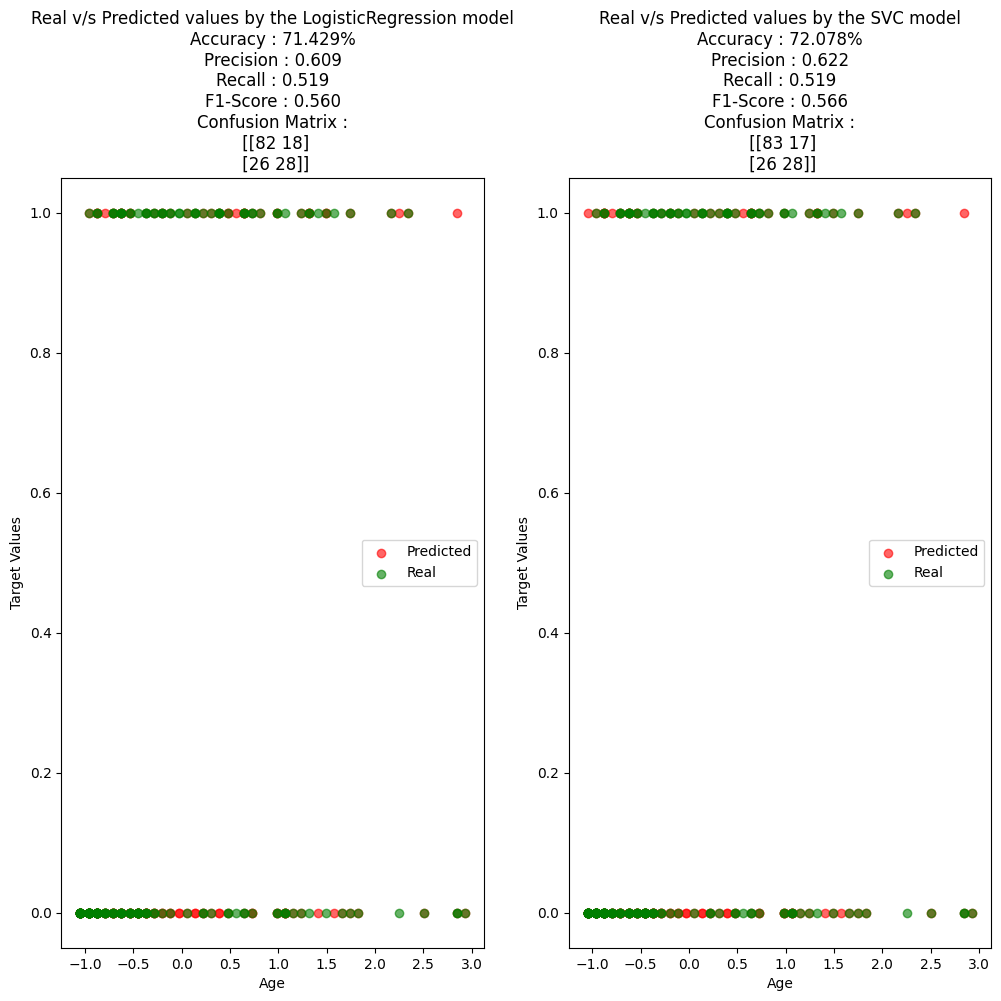

In [ ]:
plot_real_pred_values(
                     y_test=y_test,
                     X_test = X_test,
                     feature = "Age",
                     model1 = model,
                     model2 = model1)

# Now looking at the results we see a nearly similar performance by both the models of a `72-71 %` of accuracy so we can concur that either the data has non-linear patterns that cannot be captured by linearly separable decision classifiers